In [1]:
import numpy as np
from scipy.optimize import fsolve
import matplotlib.pyplot as plt

# PART A 
## Reproduces Figure 2: x = A^(1/3) and y = Z/A vs Fermi momentum p_F

In [23]:
# Empirical liquid-drop constants, Eq. (20)

a_v = 15.71511   # MeV
a_s = 17.53638   # MeV
a_c = 0.71363    # MeV
a_a = 23.37837   # MeV

m_n = 939.565    # MeV
m_p = 938.272    # MeV
dm  = m_n - m_p  # Delta m

C_ell = 3.40665e-3   # lattice coefficient, Eq. (13)
hbar_c = 197.32698  # MeV*fm

In [3]:
# Zero-density reference point, Eq. (23): solve Eqs. (21a)-(21b)

def eqs_zero_density(v):
    x, y = v
    eq1 = -a_s / x**2 + 2 * a_c * x * y**2
    eq2 = -dm + 2 * a_c * x**2 * y - 4 * a_a * (1 - 2 * y)
    return [eq1, eq2]

In [4]:
x0, y0 = fsolve(eqs_zero_density, [3.9, 0.45])
print(f"Zero-density solution:  x0 = {x0:.6f}   y0 = {y0:.6f}")

Zero-density solution:  x0 = 3.906123   y0 = 0.454046


It **matches** the paper: x0 = 3.906, y0 = 0.454

In [6]:
# Exact solution at finite p_F: solve Eqs. (26a)-(26b)

def a_c_tilde(pF):
    # Renormalized Coulomb coefficient, Eq. (27)
    return a_c - C_ell * pF

In [7]:
def eqs_finite_density(v, pF):
    x, y = v
    ac_t = a_c_tilde(pF)
    eq1 = -a_s / x**2 + 2 * ac_t * x * y**2
    eq2 = -dm + 2 * ac_t * x**2 * y - 4 * a_a * (1 - 2 * y) + y**(1/3) * pF
    return [eq1, eq2]

In [8]:
pF_grid = np.linspace(0, 40, 400)  # MeV

In [9]:
x_exact = np.zeros_like(pF_grid)
y_exact = np.zeros_like(pF_grid)

In [10]:
guess = [x0, y0]
for i, pF in enumerate(pF_grid):
    sol = fsolve(eqs_finite_density, guess, args=(pF,))
    x_exact[i], y_exact[i] = sol
    guess = sol  # continuation: use previous solution as next guess 

In [11]:
# First-order (linear) approximation, Eqs. (29a)-(29b)

C1 = 4 * a_a / (x0**2 * a_c)
C2 = 1 / (2 * x0**2 * y0**(2/3))
print(f"C1 = {C1:.5f}   C2 = {C2:.5f}")

C1 = 8.58834   C2 = 0.05547


It **matches** the paper: C1 = 8.58843, C2 = 0.05547

In [13]:
def x_linear(pF):
    slope = ((C1 - 1) * C_ell + 2 * C2) / (3 * C1 - 1)
    return x0 * (1 + slope * pF / a_c)


In [14]:
def y_linear(pF):
    slope = (3 * C2 - C_ell) / (3 * C1 - 1)
    return y0 * (1 - slope * pF / a_c)

In [15]:
x_lin = x_linear(pF_grid)
y_lin = y_linear(pF_grid)

In [16]:
#  Closed-form C_ell = 0 (no-lattice) solution, Eqs. (32a)-(32b)
#  These are parametric in y, so we sweep y and get (x, pF) pairs,
#  then sort by pF for plotting.

y_sweep = np.linspace(0.30, y0, 400)  # y decreases from y0 as density increases

x_c0 = (a_s / (2 * a_c * y_sweep**2))**(1/3)
pF_c0 = (dm - 2 * a_c * x_c0**2 * y_sweep + 4 * a_a * (1 - 2 * y_sweep)) / y_sweep**(1/3)

In [17]:
# keep only physical branch: pF >= 0, sort by pF
mask = pF_c0 >= 0
pF_c0, x_c0, y_c0 = pF_c0[mask], x_c0[mask], y_sweep[mask]
order = np.argsort(pF_c0)
pF_c0, x_c0, y_c0 = pF_c0[order], x_c0[order], y_c0[order]


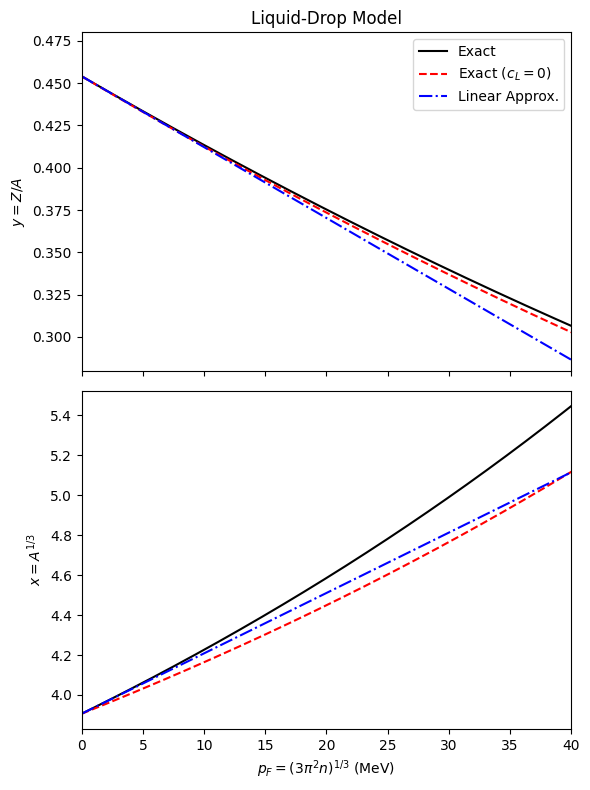

In [18]:
# Plot - reproduces Figure 2

fig, (ax_y, ax_x) = plt.subplots(2, 1, figsize=(6, 8), sharex=True)

ax_y.plot(pF_grid, y_exact, 'k-',  label='Exact')
ax_y.plot(pF_c0,  y_c0,    'r--', label=r'Exact ($c_L=0$)')
ax_y.plot(pF_grid, y_lin,  'b-.', label='Linear Approx.')
ax_y.set_ylabel(r'$y = Z/A$')
ax_y.set_title('Liquid-Drop Model')
ax_y.legend()
ax_y.set_ylim(0.28, 0.48)

ax_x.plot(pF_grid, x_exact, 'k-')
ax_x.plot(pF_c0,  x_c0,    'r--')
ax_x.plot(pF_grid, x_lin,  'b-.')
ax_x.set_ylabel(r'$x = A^{1/3}$')
ax_x.set_xlabel(r'$p_F = (3\pi^2 n)^{1/3}$ (MeV)')
ax_x.set_xlim(0, 40)

plt.tight_layout()


# PART B

In [ ]:
# 2. Build the discrete candidate-nucleus table: pF, x, y, Z, N, A
#    (pF is added later as the sweep variable -- here we build the static
#     Z,N,A,x,y,eps_n part of the table, which does not depend on pF)
Z_range = np.arange(20, 80)     # candidate proton numbers
N_range = np.arange(20, 260)    # candidate neutron numbers (widened to check for boundary artifacts)

ZZ, NN = np.meshgrid(Z_range, N_range, indexing='ij')
ZZ = ZZ.ravel()
NN = NN.ravel()
AA = ZZ + NN

keep = NN >= ZZ                 # keep neutron-rich / symmetric side only
ZZ, NN, AA = ZZ[keep], NN[keep], AA[keep]

xx = AA**(1/3)
yy = ZZ / AA

# Nuclear contribution per nucleon, Eq. (19)
eps_n_table = m_p * yy + m_n * (1 - yy) - a_v + a_s / xx \
              + a_c * xx**2 * yy**2 + a_a * (1 - 2 * yy)**2

print(f"Candidate table built: {len(ZZ)} nuclei "
      f"(Z in [{Z_range.min()},{Z_range.max()}], "
      f"N in [{N_range.min()},{N_range.max()}])")


Candidate table built: 12630 nuclei (Z in [20,79], N in [20,259])


In [ ]:
# 3. Sweep p_F, minimize chemical potential mu(x,y,pF) over the table
#    mu(x,y,pF) = eps_n(x,y) + y^(4/3) pF - (4/3) C_ell x^2 y^2 pF   [Eq.24b]
pF_grid = np.linspace(0.5, 40, 400)  # MeV

Z_best = np.zeros_like(pF_grid)
N_best = np.zeros_like(pF_grid)
A_best = np.zeros_like(pF_grid)
mu_best = np.zeros_like(pF_grid)

for i, pF in enumerate(pF_grid):
    mu = eps_n_table + yy**(4/3) * pF - (4/3) * C_ell * xx**2 * yy**2 * pF
    j = np.argmin(mu)
    Z_best[i], N_best[i], A_best[i] = ZZ[j], NN[j], AA[j]
    mu_best[i] = mu[j]


In [ ]:
# 4. Neutron-drip cutoff: stop once mu_min >= m_n
drip_mask = mu_best < m_n
if drip_mask.any():
    i_drip = np.argmax(~drip_mask) if (~drip_mask).any() else len(pF_grid)
    pF_drip = pF_grid[i_drip - 1] if i_drip > 0 else pF_grid[-1]
else:
    i_drip = len(pF_grid)
    pF_drip = pF_grid[-1]

pF_plot   = pF_grid[:i_drip]
Z_plot    = Z_best[:i_drip]
N_plot    = N_best[:i_drip]

print(f"Estimated neutron-drip Fermi momentum: pF_drip ~ {pF_drip:.1f} MeV")
print(f"Nucleus just before drip: Z={Z_plot[-1]:.0f}, N={N_plot[-1]:.0f}, "
      f"A={Z_plot[-1]+N_plot[-1]:.0f}")


Estimated neutron-drip Fermi momentum: pF_drip ~ 38.8 MeV
Nucleus just before drip: Z=60, N=162, A=222


In [ ]:
# 5. Convert p_F -> approximate mass density (for an x-axis like Fig 6/7)
#    n [fm^-3] = pF_fm^3 / (3 pi^2),  pF_fm = pF_MeV / hbar_c
#    rho [g/cm^3] ~ n[fm^-3] * 1e39 * m_u(g)   (rough, ignores binding energy)
m_u_grams = 1.66054e-24
pF_fm = pF_plot / hbar_c
n_fm3 = pF_fm**3 / (3 * np.pi**2)
rho = n_fm3 * 1e39 * m_u_grams  # g/cm^3


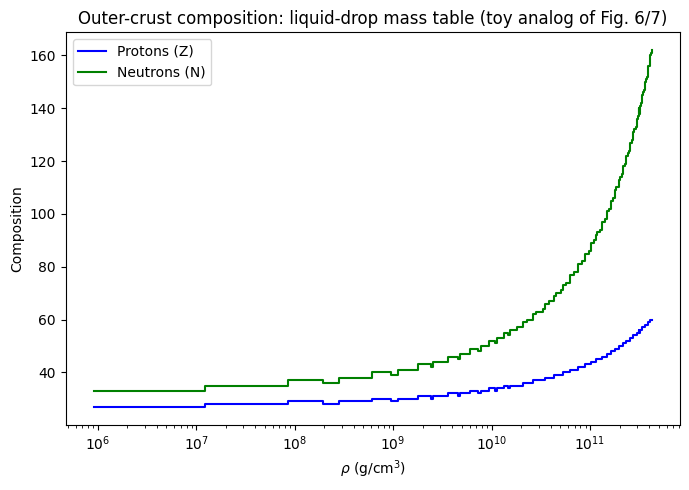

In [ ]:
# Plot -- staircase composition, in the style of Figs. 6-7
fig, ax = plt.subplots(figsize=(7, 5))
ax.step(rho, Z_plot, where='post', color='blue', label='Protons (Z)')
ax.step(rho, N_plot, where='post', color='green', label='Neutrons (N)')
ax.set_xscale('log')
ax.set_xlabel(r'$\rho$ (g/cm$^3$)')
ax.set_ylabel('Composition')
ax.set_title('Outer-crust composition: liquid-drop mass table (toy analog of Fig. 6/7)')
ax.legend()
plt.tight_layout()
